# IV surface diagnostics

This notebook interrogates the IV-analysis panel before any surface fitting. It separates valid midpoint IV observations from failed inversions, compares calculated IV with the vendor benchmark, and inspects raw OTM smiles and quote quality.

No smoothing, interpolation, liquidity filter, or surface model is applied here.

In [20]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PANEL_PATH = Path("../data/processed/spx_iv_panel_2025-08-29.csv")
panel = pd.read_csv(PANEL_PATH, parse_dates=["quote_date", "expiry_date"])
panel.shape

(14852, 29)

## 1. IV inversion coverage

Start with the number of observations produced by the panel:

$$
N_{\mathrm{panel}},\quad N_{\mathrm{valid\ IV}},\quad N_{\mathrm{invalid\ IV}},\quad N_{\mathrm{OTM}},\quad N_{\mathrm{surface}}.
$$

A failed inversion is retained as `mid_iv = NaN`; it is not treated as a liquidity filter. The breakdowns below show whether failures are concentrated by option type, time to expiry, or log-moneyness.

In [21]:
summary = pd.Series({
    "N_panel": len(panel),
    "N_valid_IV": panel["mid_iv"].notna().sum(),
    "N_invalid_IV": panel["mid_iv"].isna().sum(),
    "N_OTM": panel["is_otm"].sum(),
    "N_use_for_surface": panel["use_for_surface"].sum(),
})
summary

N_panel              14852
N_valid_IV           14453
N_invalid_IV           399
N_OTM                 7426
N_use_for_surface     7426
dtype: int64

In [22]:
failed_iv = panel[panel["mid_iv"].isna()].copy()
failed_iv["dte_bucket"] = pd.cut(
    failed_iv["days_to_expiry"],
    bins=[0, 7, 30, 90, 365, np.inf],
    labels=["1-7", "8-30", "31-90", "91-365", "366+"],
)
failed_iv["moneyness_bucket"] = pd.cut(
    failed_iv["log_moneyness"],
    bins=[-np.inf, -0.2, -0.05, 0.05, 0.2, np.inf],
    labels=["far_below_forward", "below_forward", "near_ATM", "above_forward", "far_above_forward"],
)
failure_by_type = failed_iv.groupby("option_type", observed=True).size().rename("n_failures")
failure_by_dte = failed_iv.groupby("dte_bucket", observed=True).size().rename("n_failures")
failure_by_moneyness = failed_iv.groupby("moneyness_bucket", observed=True).size().rename("n_failures")
failure_by_type, failure_by_dte, failure_by_moneyness

(option_type
 call    340
 put      59
 Name: n_failures, dtype: int64,
 dte_bucket
 1-7       216
 8-30      127
 31-90      47
 91-365      9
 Name: n_failures, dtype: int64,
 moneyness_bucket
 far_below_forward    202
 below_forward        124
 near_ATM              64
 above_forward          1
 far_above_forward      8
 Name: n_failures, dtype: int64)

## 2. Calculated IV versus vendor IV

For observations where both values exist, compare

$$
\Delta\sigma=\sigma_{\mathrm{mid}}-\sigma_{\mathrm{vendor}}.
$$

The values need not agree exactly because the vendor may use different forwards, discounting, prices, conventions, or filters. We are looking for gross disagreement, bias, and obvious outliers.

In [23]:
comparison = panel.dropna(subset=["mid_iv", "vendor_iv"]).copy()
comparison["iv_difference"] = comparison["mid_iv"] - comparison["vendor_iv"]
comparison[["mid_iv", "vendor_iv", "iv_difference"]].describe()

,mid_iv,vendor_iv,iv_difference
count,13326.000000,13326.000000,13326.000000
mean,0.208936,0.209508,-0.000572
std,0.165722,0.166655,0.017892
min,0.034800,0.046791,-0.198794
25%,0.116926,0.118383,-0.001500
50%,0.163016,0.163086,-0.000431
75%,0.241533,0.236172,0.002017
max,2.943162,2.943847,0.151143


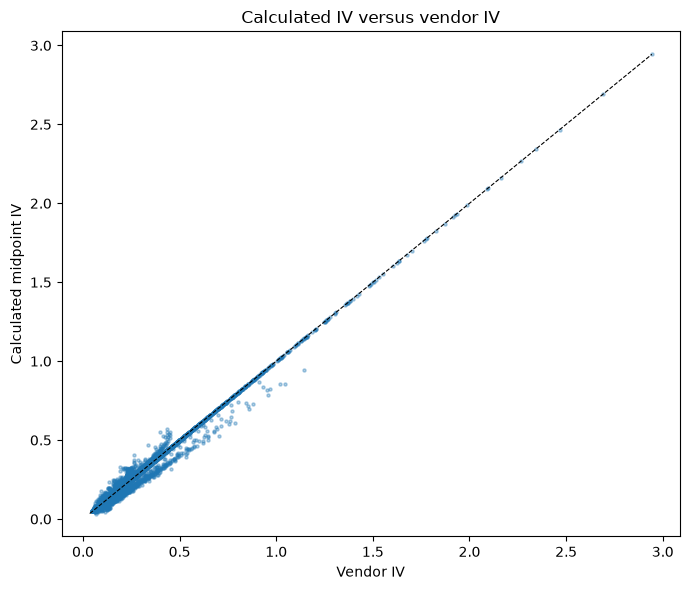

In [24]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(comparison["vendor_iv"], comparison["mid_iv"], s=5, alpha=0.35)
limits = [
    min(comparison["vendor_iv"].min(), comparison["mid_iv"].min()),
    max(comparison["vendor_iv"].max(), comparison["mid_iv"].max()),
]
ax.plot(limits, limits, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Vendor IV")
ax.set_ylabel("Calculated midpoint IV")
ax.set_title("Calculated IV versus vendor IV")
plt.tight_layout()

## 3. Raw OTM smiles

Use only observations marked `use_for_surface` and plot the calculated IV against log-moneyness:

$$
k=\log(K/F),\qquad \sigma=\sigma_{\mathrm{mid}}.
$$

The selected expiries represent short, intermediate, and long maturities. These are raw scatter plots: no curve is fitted and no smoothing is applied. We want to see whether the smiles are broadly coherent before choosing a surface model.

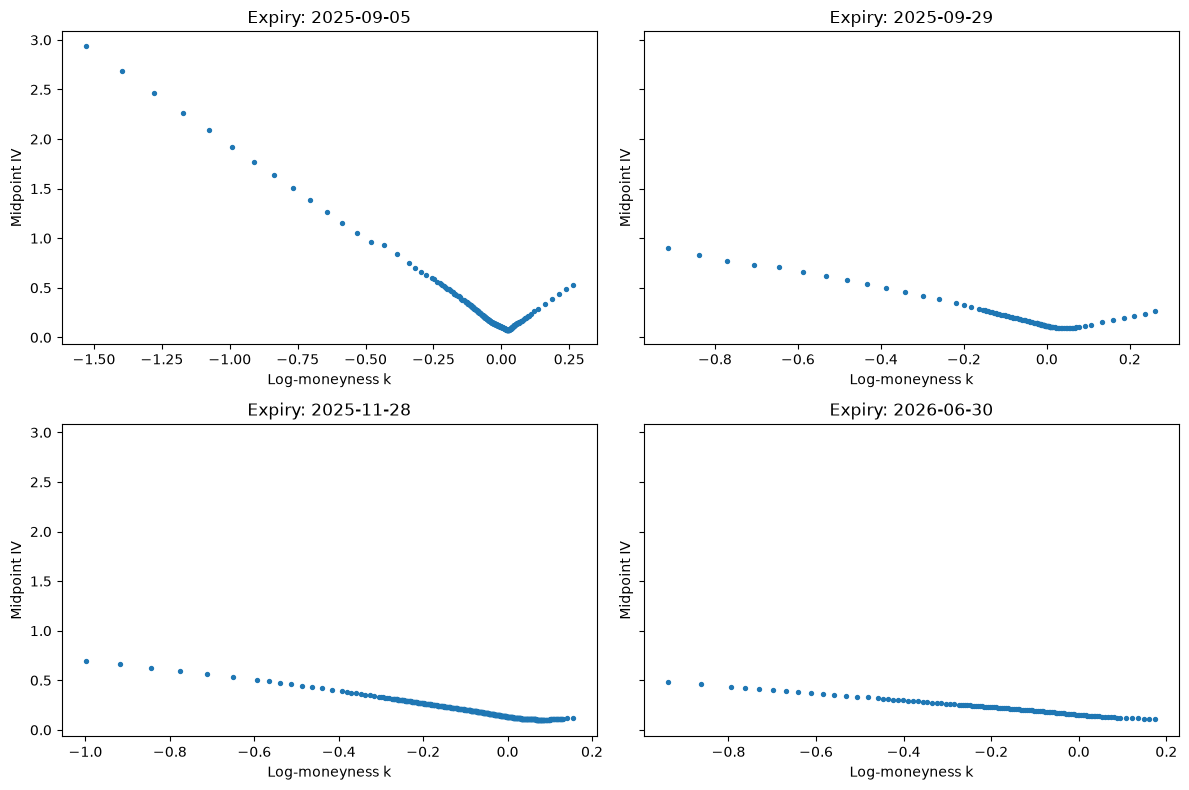

In [25]:
surface_rows = panel[panel["use_for_surface"]].copy()
expiry_table = surface_rows[["expiry_date", "days_to_expiry"]].drop_duplicates()
target_dtes = [7, 30, 90, 365]
selected_expiries = expiry_table.iloc[
    [(expiry_table["days_to_expiry"] - target).abs().argmin() for target in target_dtes]
]["expiry_date"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
for ax, expiry in zip(axes.flat, selected_expiries):
    sample = surface_rows[surface_rows["expiry_date"] == expiry]
    ax.scatter(sample["log_moneyness"], sample["mid_iv"], s=8)
    ax.set_title(f"Expiry: {expiry.date()}")
    ax.set_xlabel("Log-moneyness k")
    ax.set_ylabel("Midpoint IV")

plt.tight_layout()

In [26]:
surface_comparison = surface_rows.dropna(subset=["vendor_iv"]).copy()
surface_comparison["iv_difference"] = (
    surface_comparison["mid_iv"] - surface_comparison["vendor_iv"]
)
surface_comparison[["mid_iv", "vendor_iv", "iv_difference"]].describe()

,mid_iv,vendor_iv,iv_difference
count,7426.000000,7426.000000,7426.000000
mean,0.232277,0.232644,-0.000367
std,0.204115,0.204337,0.001366
min,0.049059,0.046791,-0.005305
25%,0.118413,0.119363,-0.001181
50%,0.170789,0.171746,-0.000631
75%,0.264192,0.265000,0.000574
max,2.943162,2.943847,0.006049


## 4. Quote quality around the usable observations

If the raw smiles contain spikes or discontinuities, relate them back to the original quote fields. The following views expose midpoint IV, relative spread, volume, open interest, and the difference from the vendor IV without imposing a cutoff.

This is the point at which we can decide whether zero bids, wide spreads, or a moneyness range explain the problematic observations. No such rule is applied in this notebook.

In [27]:
surface_rows[["mid_iv", "relative_spread", "volume", "open_interest"]].describe()

,mid_iv,relative_spread,volume,open_interest
count,7426.000000,7426.000000,7426.000000,7426.000000
mean,0.232277,0.193616,125.773903,492.496633
std,0.204115,0.466916,620.008127,3075.428761
min,0.049059,0.000000,0.000000,0.000000
25%,0.118413,0.007859,0.000000,17.000000
50%,0.170789,0.019048,3.000000,76.000000
75%,0.264192,0.074074,31.000000,244.000000
max,2.943162,2.000000,20747.000000,73690.000000


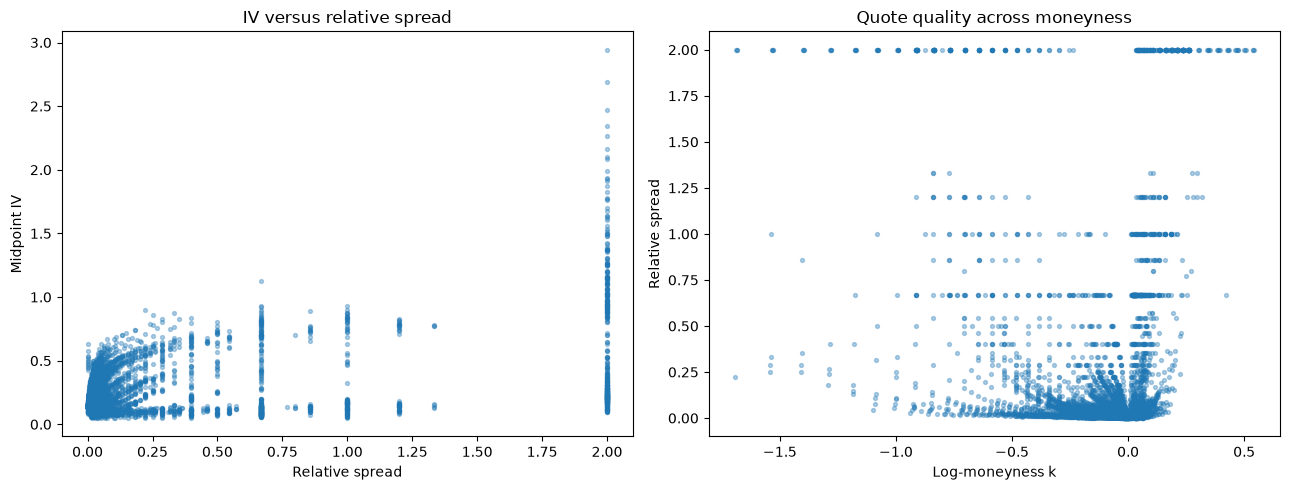

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(surface_rows["relative_spread"], surface_rows["mid_iv"], s=8, alpha=0.35)
axes[0].set_xlabel("Relative spread")
axes[0].set_ylabel("Midpoint IV")
axes[0].set_title("IV versus relative spread")
axes[1].scatter(surface_rows["log_moneyness"], surface_rows["relative_spread"], s=8, alpha=0.35)
axes[1].set_xlabel("Log-moneyness k")
axes[1].set_ylabel("Relative spread")
axes[1].set_title("Quote quality across moneyness")
plt.tight_layout()

## Quote summary by moneyness and DTE

This table summarises the actual OTM surface sample before any quote-cleaning rule is chosen. It is intended to show where zero bids, wide relative spreads, and large IVs occur. The statistics are diagnostic only.

In [29]:
summary_rows = surface_rows.copy()
summary_rows["dte_bucket"] = pd.cut(
    summary_rows["days_to_expiry"],
    bins=[0, 7, 30, 90, 365, np.inf],
    labels=["1-7", "8-30", "31-90", "91-365", "366+"],
)
summary_rows["moneyness_bucket"] = pd.cut(
    summary_rows["log_moneyness"],
    bins=[-np.inf, -0.2, -0.05, 0.05, 0.2, np.inf],
    labels=["far_below_forward", "below_forward", "near_ATM", "above_forward", "far_above_forward"],
)
summary_rows["zero_bid"] = summary_rows["best_bid"].eq(0)

quote_summary = summary_rows.groupby(
    ["moneyness_bucket", "dte_bucket"], observed=True
).agg(
    n_observations=("mid_iv", "size"),
    pct_zero_bid=("zero_bid", "mean"),
    median_midpoint=("mid_price", "median"),
    median_relative_spread=("relative_spread", "median"),
    p95_relative_spread=("relative_spread", lambda values: values.quantile(0.95)),
    median_iv=("mid_iv", "median"),
    p95_iv=("mid_iv", lambda values: values.quantile(0.95)),
)
quote_summary["pct_zero_bid"] = 100 * quote_summary["pct_zero_bid"]
quote_summary

n_observations  pct_zero_bid  median_midpoint  \
moneyness_bucket  dte_bucket                                                  
far_below_forward 1-7                     74     67.567568           0.0250   
                  8-30                   312     25.320513           0.2750   
                  31-90                  490      3.673469           2.2625   
                  91-365                 421      0.000000          19.9500   
below_forward     1-7                    238      0.000000           0.4000   
                  8-30                   656      0.000000           3.9750   
                  31-90                  733      0.000000          19.2500   
                  91-365                 542      0.000000          77.5750   
near_ATM          1-7                    480      3.750000           1.0000   
                  8-30                  1325      0.000000          23.3500   
                  31-90                  821      0.000000          62.1000   
                  91-365                 464      0.000000         150.1750   
above_forward     1-7                     67     79.104478           0.0250   
                  8-30                   237     21.097046           0.1250   
                  31-90                  244      1.229508           1.4125   
                  91-365                 190      0.000000          13.3000   
far_above_forward 1-7                     12    100.000000           0.0250   
                  8-30                    49    100.000000           0.0250   
                  31-90                   46     84.782609           0.0500   
                  91-365                  25     44.000000           0.1250   

                              median_relative_spread  p95_relative_spread  \
moneyness_bucket  dte_bucket                                                
far_below_forward 1-7                       2.000000             2.000000   
                  8-30                      0.400000             2.000000   
                  31-90                     0.060606             1.200000   
                  91-365                    0.015666             0.084034   
below_forward     1-7                       0.200000             0.666667   
                  8-30                      0.043478             0.133333   
                  31-90                     0.013857             0.041494   
                  91-365                    0.005902             0.011047   
near_ATM          1-7                       0.070588             1.000000   
                  8-30                      0.012987             0.138295   
                  31-90                     0.006336             0.025974   
                  91-365                    0.004369             0.008253   
above_forward     1-7                       2.000000             2.000000   
                  8-30                      0.666667             2.000000   
                  31-90                     0.100000             1.000000   
                  91-365                    0.026087             0.157231   
far_above_forward 1-7                       2.000000             2.000000   
                  8-30                      2.000000             2.000000   
                  31-90                     2.000000             2.000000   
                  91-365                    1.333333             2.000000   

                              median_iv    p95_iv  
moneyness_bucket  dte_bucket                       
far_below_forward 1-7          1.045694  2.294451  
                  8-30         0.625495  1.250915  
                  31-90        0.413496  0.837021  
                  91-365       0.315830  0.633000  
below_forward     1-7          0.275668  0.484912  
                  8-30         0.242866  0.362333  
                  31-90        0.221166  0.295783  
                  91-365       0.203048  0.250614  
near_ATM          1-7          0.100500  0.170583  
                  8-30  

## Smiles after the initial quote screen

For comparison, apply the first simple surface-fitting screen:

```python
use_for_fit = (
    use_for_surface
    & (best_bid > 0)
    & (relative_spread <= 0.50)
)
```

The following plot reproduces the raw smile/smirk view using only `use_for_fit` observations.

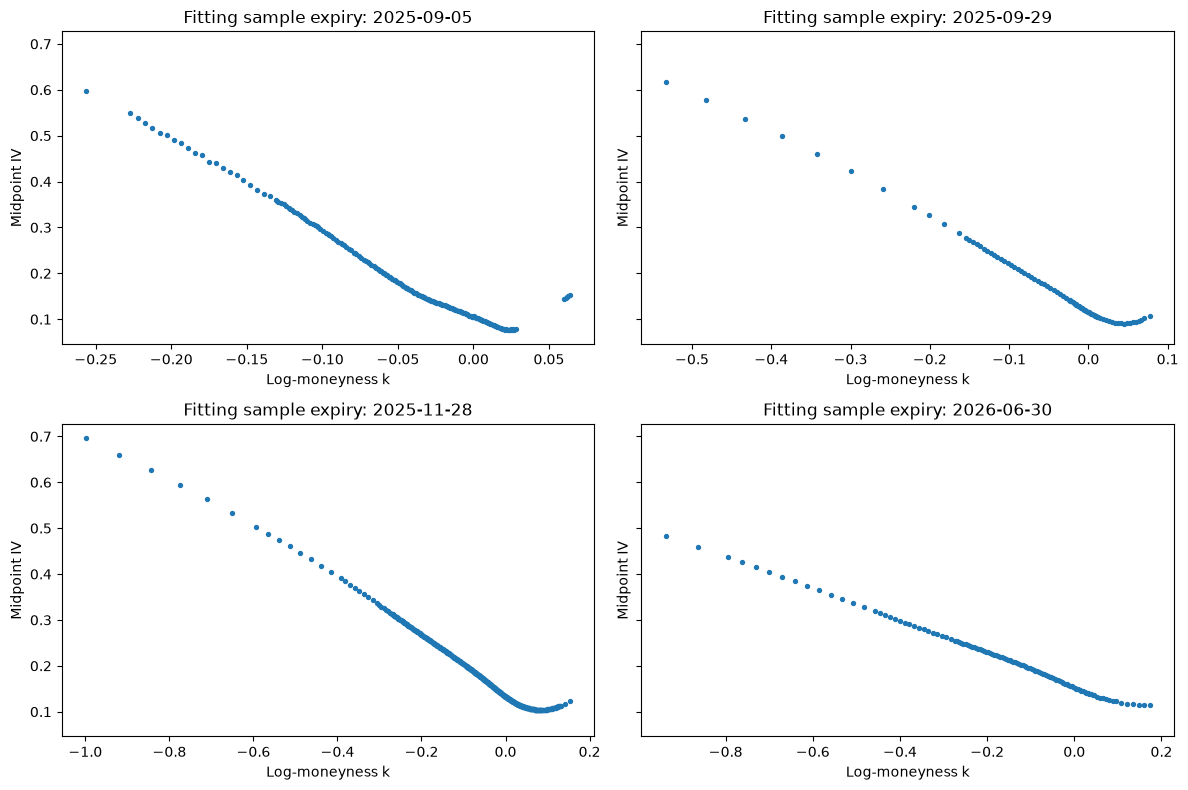

In [30]:
panel["use_for_fit"] = (
    panel["use_for_surface"]
    & panel["best_bid"].gt(0)
    & panel["relative_spread"].le(0.50)
)
fit_rows = panel[panel["use_for_fit"]].copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
for ax, expiry in zip(axes.flat, selected_expiries):
    sample = fit_rows[fit_rows["expiry_date"] == expiry]
    ax.scatter(sample["log_moneyness"], sample["mid_iv"], s=8)
    ax.set_title(f"Fitting sample expiry: {expiry.date()}")
    ax.set_xlabel("Log-moneyness k")
    ax.set_ylabel("Midpoint IV")

plt.tight_layout()